**IMPORTING REQUIRED LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv('/content/drive/MyDrive/ratings.csv',header=None)
#as there is no proper header , we are going to name the columns later
df.head()

,0,1,2,3
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [4]:
df.columns=['userid','productid','ratings','timestamp']
print('overall info of the dataset')
print('---------------------------')
print(df.info())
print(df.head())

overall info of the dataset
---------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userid     object 
 1   productid  object 
 2   ratings    float64
 3   timestamp  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB
None
           userid   productid  ratings   timestamp
0   AKM1MP6P0OYPR  0132793040      5.0  1365811200
1  A2CX7LUOHB2NDG  0321732944      5.0  1341100800
2  A2NWSAGRHCP8N5  0439886341      1.0  1367193600
3  A2WNBOD3WNDNKT  0439886341      3.0  1374451200
4  A1GI0U4ZRJA8WN  0439886341      1.0  1334707200


In [5]:
#checking the nullvalues
df.isnull().sum()

,0
userid,0
productid,0
ratings,0
timestamp,0


In [6]:
df.duplicated().sum()#checking the duplicated values

np.int64(0)

In [7]:
print('unique users of the data: ',df['userid'].nunique())
print("unique products present in data:",df['productid'].nunique())

unique users of the data:  4201696
unique products present in data: 476002


In [8]:
print('overall shape of the data:')
print('--------------------------')
print(df.shape)

overall shape of the data:
--------------------------
(7824482, 4)


##### as you can see there are no null values are present in the data
* we dont require the timestamp dataset, so we are dropping the timestamp column completely

In [9]:
df.drop(columns='timestamp',inplace=True)

In [10]:
df.head()#after removing the timestamp column

,userid,productid,ratings
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [11]:
df["ratings"].value_counts().sort_index()#it typically shows how many 1,2,3,4 and 5 stars ratings is given by how many users on how  it is shown

,count
ratings,
1.0,901765
2.0,456322
3.0,633073
4.0,1485781
5.0,4347541


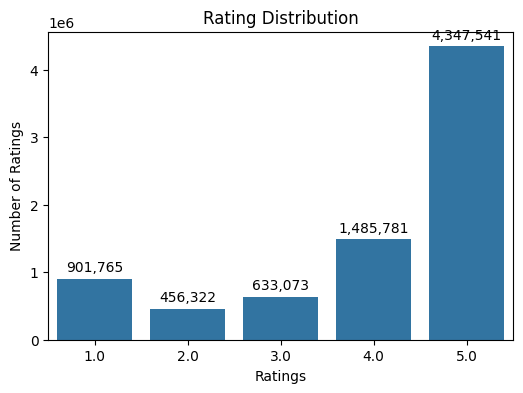

In [12]:
#VISUALISATION OF NO. OF RATINGS
plt.figure(figsize=(6, 4))
ax=sns.countplot(data=df, x="ratings")#it shows the ratings in the barchart format
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Number of Ratings")
for container in ax.containers:
    labels = [f"{int(bar.get_height()):,}" for bar in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.show()

In [13]:
#getting the top 10 most rated products
top_prod=df['productid'].value_counts(ascending=False).head(10)
top_prod

,count
productid,
B0074BW614,18244
B00DR0PDNE,16454
B007WTAJTO,14172
B0019EHU8G,12285
B006GWO5WK,12226
B003ELYQGG,11617
B003ES5ZUU,10276
B007R5YDYA,9907
B00622AG6S,9823


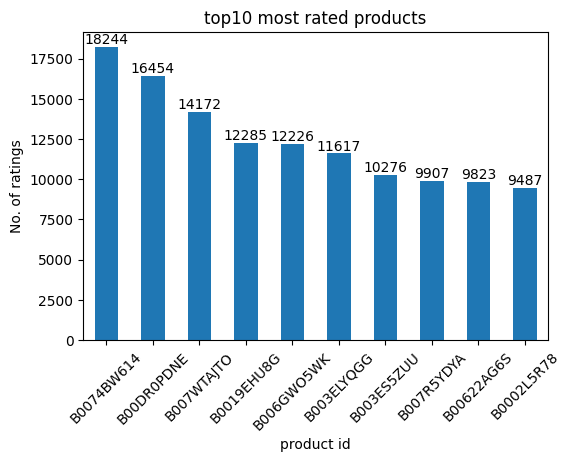

In [14]:
#VISUALIZATION OF TOP 10 RATED PRODUCTS
plt.figure(figsize=(6,4))
ax=top_prod.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt="%d")
plt.title('top10 most rated products')
plt.xlabel("product id")
plt.ylabel('No. of ratings')
plt.xticks(rotation=45)
plt.show()

In [15]:
#getting the most users who have bought the products
top_users=df['userid'].value_counts().head(10)
top_users

,count
userid,
A5JLAU2ARJ0BO,520
ADLVFFE4VBT8,501
A3OXHLG6DIBRW8,498
A6FIAB28IS79,431
A680RUE1FDO8B,406
A1ODOGXEYECQQ8,380
A36K2N527TXXJN,314
A2AY4YUOX2N1BQ,311
AWPODHOB4GFWL,308


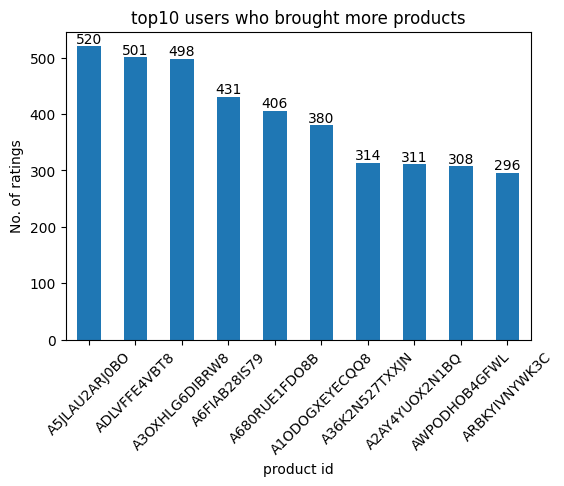

In [16]:
#VISUALIZATION OF TOP 10 USERS WHO BOUGHT MORE PRODUCTS
plt.figure(figsize=(6,4))
rx=top_users.plot(kind='bar')
rx.bar_label(rx.containers[0], fmt="%d")
plt.title('top10 users who brought more products')
plt.xlabel("product id")
plt.ylabel('No. of ratings')
plt.xticks(rotation=45)
plt.show()

In [17]:
#CHECKING THE NO.OF RATINGS GIVEN BY EVERY USER SUMMARY
ratings_per_user=df.groupby('userid')['ratings'].count()
print('------------------------')
print('ratings per user summary')
print("------------------------")
ratings_per_user.describe().apply(lambda x: f"{x:,.2f}")

------------------------
ratings per user summary
------------------------


,ratings
count,"4,201,696.00"
mean,1.86
std,2.89
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,520.00


In [18]:
#Ratings Per Product Summary
ratings_per_product = df.groupby("productid")["ratings"].count()
print('----------------------------')
print('ratings_per_product_summary')
print("----------------------------")
ratings_per_product.describe()

----------------------------
ratings_per_product_summary
----------------------------


,ratings
count,476002.000000
mean,16.437918
std,112.702633
min,1.000000
25%,1.000000
50%,2.000000
75%,7.000000
max,18244.000000


lets talk about the term **DATA SPARSITY**
* Data sparsity is a condition where a dataset has a large number of missing or zero-valued entries relative to the total possible entries.
* in short the formula can be mentioned as :

$$
\text{Data Sparsity} =
\frac{\text{Number of zero/missing values}}
{\text{Total number of values}}
\times 100\%
$$




In [19]:
#checking dataset sparsity in the dataset
total_possible_ratings = df["userid"].nunique() * df["productid"].nunique()
actual_ratings = len(df)
sparsity = (1- actual_ratings / total_possible_ratings) * 100
print("Sparsity:", round(sparsity, 4), "%")
#it clearly shows that 99.99 percent ratings are missing that every user is not rating each product, this is usual in the dataset like not every user can able to buy every product and make to give a review

Sparsity: 99.9996 %


In [20]:
n_users = df['userid'].nunique()
n_products = df['productid'].nunique()
print(f"User-item matrix would be {n_users:,} x {n_products:,} = {n_users*n_products:,.0f} cells")
print(f"Only {actual_ratings:,} are filled -> {sparsity:.4f}% sparse")
print()
print(f"Users with exactly 1 rating: {(ratings_per_user==1).sum():,} ({(ratings_per_user==1).mean()*100:.1f}%)")
print()
print(f"Products with exactly 1 rating: {(ratings_per_product==1).sum():,} ({(ratings_per_product==1).mean()*100:.1f}%)")

User-item matrix would be 4,201,696 x 476,002 = 2,000,015,699,392 cells
Only 7,824,482 are filled -> 99.9996% sparse

Users with exactly 1 rating: 2,881,832 (68.6%)

Products with exactly 1 rating: 179,738 (37.8%)


In [21]:
df.describe()#description of the dataset

,ratings
count,7.824482e+06
mean,4.012337e+00
std,1.380910e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


In [22]:
from scipy.sparse import csr_matrix

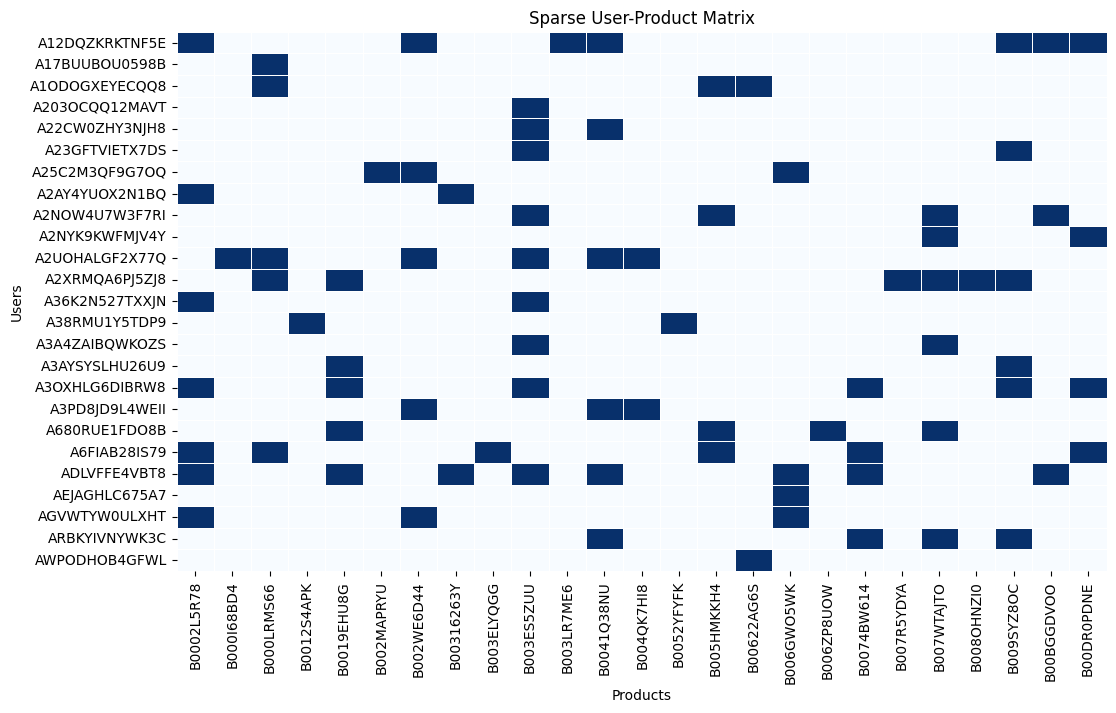

In [23]:
##JUST SHOWING THE SAMPLE OF THE SPARSITY DATASET WHICH IN SMALL EXAMPLE THAT EVERY CANT BE ABLE TO RATE EVERY PRODUCT, THE MISSING BOXES IN THE DATA
#REPRESENTS THE 'MISSING RATINGS' BY THE USER TO  THE GIVEN PRODUCT
sample_users = df["userid"].value_counts().head(30).index
sample_products = df["productid"].value_counts().head(30).index

small_matrix = df[
    df["userid"].isin(sample_users) &
    df["productid"].isin(sample_products)
].pivot_table(
    index="userid",
    columns="productid",
    values="ratings"
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    small_matrix.notnull(),
    cmap="Blues",
    cbar=False,
    linewidths=0.5
)

plt.title("Sparse User-Product Matrix")
plt.xlabel("Products")
plt.ylabel("Users")

plt.show()

# Model Building & Evaluation #

In [24]:
#IMPORTING REQUIRED LIBRARIES FOR THE MODEL BUILDING
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.cluster import KMeans,MiniBatchKMeans,dbscan,AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD

In [25]:
#FILTERING ACTIVE USERS AND PRODUCTS

user_counts = df["userid"].value_counts()
product_counts = df["productid"].value_counts()

active_users = user_counts[user_counts >= 10].index
active_products = product_counts[product_counts >= 10].index

model_df = df[
    df["userid"].isin(active_users) &
    df["productid"].isin(active_products)
].copy()

print("Original data shape:", df.shape)
print("Filtered data shape:", model_df.shape)

Original data shape: (7824482, 3)
Filtered data shape: (949416, 3)


recommendation systems need enough rating history. Users with very few ratings and products with few ratings wont provide strong patterns. so i kept users with atleast 10 ratings

In [26]:
model_df["user_index"] = model_df["userid"].astype("category").cat.codes
model_df["product_index"] = model_df["productid"].astype("category").cat.codes

user_mapping = model_df[["userid", "user_index"]].drop_duplicates()
product_mapping = model_df[["productid", "product_index"]].drop_duplicates()

model_df.head()

,userid,productid,ratings,user_index,product_index
16,A3N7T0DY83Y4IG,0528881469,3.0,44230,0
17,A1H8PY3QHMQQA0,0528881469,2.0,7950,0
62,A2TKKYL3GKFS2M,0594033926,5.0,30399,1
89,AAZ084UMH8VZ2,0594451647,5.0,51589,2
94,A3BY5KCNQZXV5U,0594451647,5.0,39000,2


i have given the userid as unique index value because the ml models cannot understand the text ids , so i have converted the user and product ids into numerical indexes

In [27]:
user_product_matrix = csr_matrix(
    (
        model_df["ratings"],
        (model_df["user_index"], model_df["product_index"])
    )
)

user_product_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 949416 stored elements and shape (63161, 85930)>

I created a user-product matrix. Rows represent users, columns represent products, and values represent ratings. Since most users rate only a few products, I used a sparse matrix to save memory.

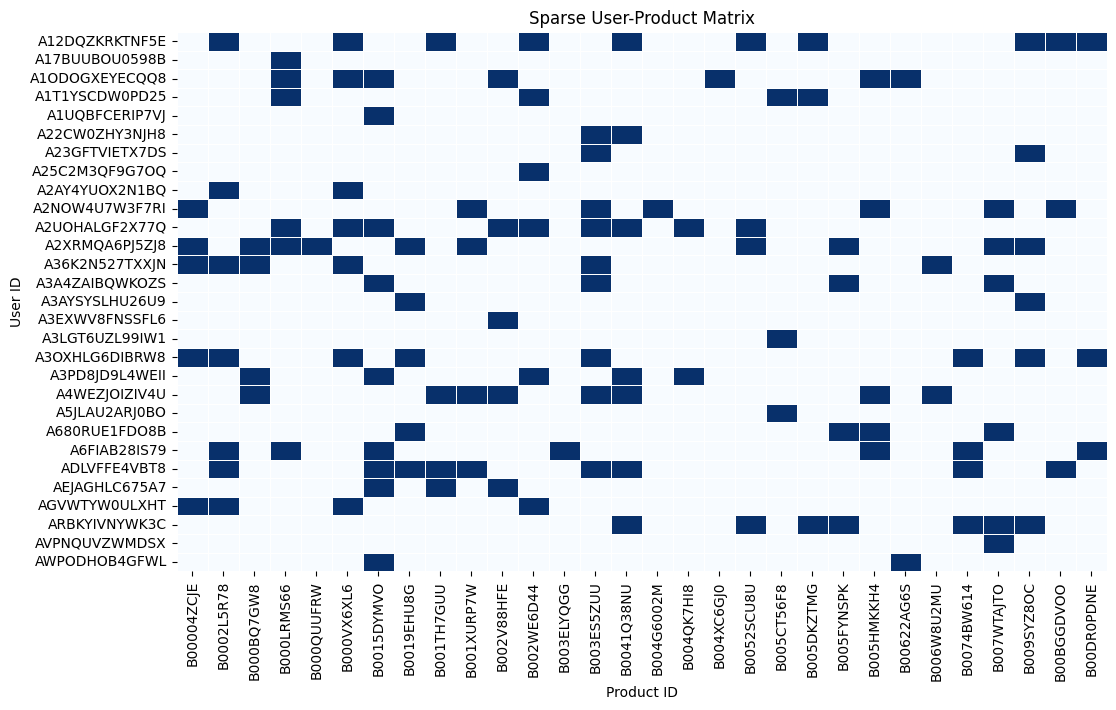

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_users = model_df["userid"].value_counts().head(30).index
sample_products = model_df["productid"].value_counts().head(30).index

small_df = model_df[
    model_df["userid"].isin(sample_users) &
    model_df["productid"].isin(sample_products)
]

small_matrix = small_df.pivot_table(
    index="userid",
    columns="productid",
    values="ratings"
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    small_matrix.notnull(),
    cmap="Blues",
    cbar=False,
    linewidths=0.5
)

plt.title("Sparse User-Product Matrix")
plt.xlabel("Product ID")
plt.ylabel("User ID")

plt.show()

* blue cell= user rated that product
* white cell= user not rated that product

popularity based model

In [29]:
popular_products = model_df.groupby("productid").agg(
    average_rating=("ratings", "mean"),
    rating_count=("ratings", "count")
).reset_index()

popular_products = popular_products[
    popular_products["rating_count"] >= 50
].sort_values(
    by=["average_rating", "rating_count"],
    ascending=False
)

popular_products.head(10)

,productid,average_rating,rating_count
57842,B005LJQPE0,4.962963,54
29332,B001W26TIW,4.958333,96
57833,B005LJQM3Y,4.937500,80
2688,B00006I53W,4.931034,58
49644,B004LU1U2M,4.927083,96
47517,B004EBUXHQ,4.922078,77
28594,B001TH7GUA,4.921348,89
47700,B004FA8NOQ,4.916667,72
2689,B00006I53X,4.914286,70
36501,B0033PRWSW,4.913793,116


This is the baseline model. It recommends products that have high average ratings and many ratings. It is not personalized, but it is useful for new users.

In [30]:
item_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=6
)

item_model.fit(user_product_matrix.T)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=6)

I trained an item-item collaborative filtering model. I used transpose .T because I want to compare products with products. Cosine similarity is used to find products with similar rating patterns.

In [31]:
def recommend_similar_products(product_id, n=5):
    product_row = product_mapping[
        product_mapping["productid"] == product_id
    ]

    if product_row.empty:
        return "Product not found"

    product_index = product_row["product_index"].values[0]

    distances, indices = item_model.kneighbors(
        user_product_matrix.T[product_index],
        n_neighbors=n + 1
    )

    recommended_indices = indices.flatten()[1:]
    similarity_scores = 1 - distances.flatten()[1:]

    result = pd.DataFrame({
        "product_index": recommended_indices,
        "similarity_score": similarity_scores
    })

    result = result.merge(product_mapping, on="product_index", how="left")

    return result[["productid", "similarity_score"]]

This function takes a product ID and recommends similar products. A similarity score closer to 1 means the products are more similar.

In [32]:
sample_product = model_df["productid"].iloc[0]

similar_products = recommend_similar_products(sample_product, 10)

similar_products

,productid,similarity_score
0,B0082BMYCQ,0.832050
1,B003Y73P44,0.665640
2,B005ZM9XGU,0.554700
3,B00852PGT0,0.341394
4,B002EL4RIY,0.320256
5,B0036QYUQA,0.277350
6,B005OM2AD4,0.273115
7,B0029LB5D4,0.240997
8,B003L11FUY,0.212718
9,B004AX6Z3Y,0.199469


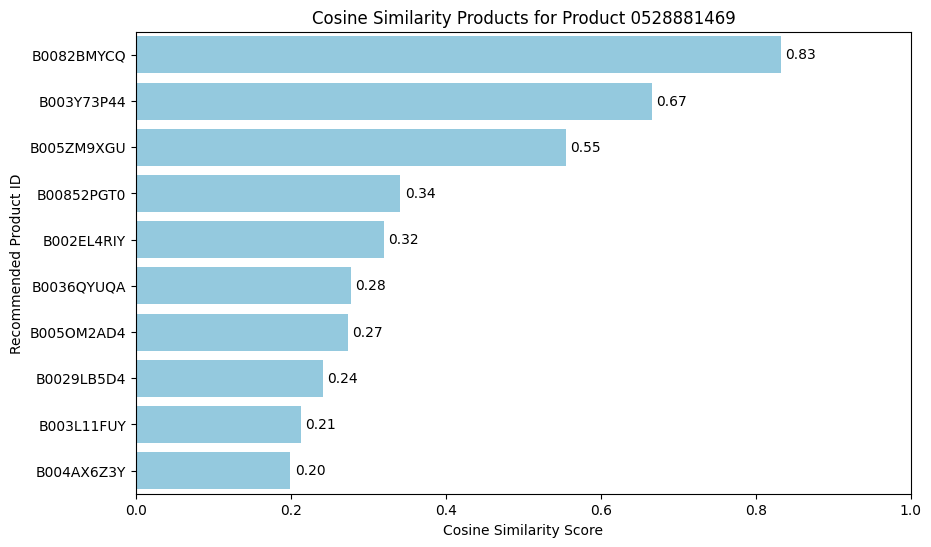

In [33]:

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=similar_products,
    x="similarity_score",
    y="productid",
    color="skyblue"
)

plt.title(f"Cosine Similarity Products for Product {sample_product}")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Recommended Product ID")
plt.xlim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

In [34]:
#Testing the recommendation model
sample_product = model_df["productid"].iloc[0]

print("Selected product:", sample_product)

recommend_similar_products(sample_product, 5)

Selected product: 0528881469


,productid,similarity_score
0,B0082BMYCQ,0.832050
1,B003Y73P44,0.665640
2,B005ZM9XGU,0.554700
3,B00852PGT0,0.341394
4,B002EL4RIY,0.320256


tested the model by selecting one product and getting five similar products based on user rating behavior.

In [35]:
def filter_min_ratings(data, min_user_ratings=5, min_product_ratings=10, max_rounds=5):

    d = data.copy()
    for i in range(max_rounds):
        user_counts = d['userid'].value_counts()
        product_counts = d['productid'].value_counts()
        keep_users = user_counts[user_counts >= min_user_ratings].index
        keep_products = product_counts[product_counts >= min_product_ratings].index

        before = len(d)
        d = d[d['userid'].isin(keep_users) & d['productid'].isin(keep_products)]
        after = len(d)

        print(f"  round {i+1}: {before:,} -> {after:,} ratings | "
              f"{d['userid'].nunique():,} users | {d['productid'].nunique():,} products")
        if before == after:
            print("  converged")
            break
    return d

MIN_USER_RATINGS = 5
MIN_PRODUCT_RATINGS = 10

print(f"Filtering to users/products with >= {MIN_USER_RATINGS} ratings each:")
df_filtered = filter_min_ratings(df, MIN_USER_RATINGS, MIN_PRODUCT_RATINGS)

retained_pct = len(df_filtered) / len(df) * 100
print(f"\nRetained {len(df_filtered):,} of {len(df):,} ratings ({retained_pct:.1f}%)")

Filtering to users/products with >= 5 ratings each:
  round 1: 7,824,482 -> 1,991,560 ratings | 253,895 users | 95,177 products
  round 2: 1,991,560 -> 1,598,462 ratings | 208,561 users | 39,407 products
  round 3: 1,598,462 -> 1,423,909 ratings | 167,070 users | 36,282 products
  round 4: 1,423,909 -> 1,378,069 ratings | 162,585 users | 32,890 products
  round 5: 1,378,069 -> 1,353,204 ratings | 157,174 users | 32,483 products

Retained 1,353,204 of 7,824,482 ratings (17.3%)


"We filtered out users and products with fewer than 10 ratings because they don't have enough data for the model to detect a pattern from, and even though that removes about around 95% of the rows, it's mostly rows that couldn't help the model anyway — and we kept the threshold as a named variable at the top of the notebook so it's easy to adjust in one place during the deployment phase."

   Iteratively drop users/products below the ratings threshold.

    This has to be iterative: removing sparse products can drop a user
    below the threshold too (and vice versa), so one pass isn't enough.
    We cap at `max_rounds` rather than running to full convergence —
    convergence keeps shrinking the dataset for many more rounds with
    rapidly diminishing returns.

In [36]:
#DIMENSIONALITY REDUCTION USING TRUNCATEDSVD
svd = TruncatedSVD(n_components=50, random_state=42)

product_features = svd.fit_transform(user_product_matrix.T)

print("Product feature shape:", product_features.shape)
print("Explained variance:", round(svd.explained_variance_ratio_.sum() * 100, 2), "%")

Product feature shape: (85930, 50)
Explained variance: 5.55 %


In [37]:
def build_sparse_matrix(data):
    """Build a CSR user-item ratings matrix plus the id<->index lookup tables."""
    user_ids = data['userid'].unique()
    product_ids = data['productid'].unique()
    user_to_idx = {u: i for i, u in enumerate(user_ids)}
    product_to_idx = {p: i for i, p in enumerate(product_ids)}

    row_idx = data['userid'].map(user_to_idx).values
    col_idx = data['productid'].map(product_to_idx).values
    values = data['ratings'].values

    matrix = csr_matrix((values, (row_idx, col_idx)),
                         shape=(len(user_ids), len(product_ids)))
    return matrix, user_to_idx, product_to_idx, user_ids, product_ids

user_product_matrix, user_to_idx, product_to_idx, user_ids, product_ids = build_sparse_matrix(df_filtered)

density = user_product_matrix.nnz / (user_product_matrix.shape[0] * user_product_matrix.shape[1])
print(f"Matrix shape: {user_product_matrix.shape}  |  non-zero entries: {user_product_matrix.nnz:,}  |  density: {density*100:.3f}%")

Matrix shape: (157174, 32483)  |  non-zero entries: 1,353,204  |  density: 0.027%


user_to_idx` / `product_to_idx` matter beyond just building the matrix — we reuse them every time we need to go from a real `userId`/`productId` back to a row/column number, including in the recommendation function in . Keeping the mappings as separate, reusable objects (instead of re-deriving them inline each time) is what keeps the rest of the notebook from silently going out of sync with itself.

In [38]:
def get_svd_embeddings(matrix, n_components=50, random_state=42):
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    embeddings = svd.fit_transform(matrix)
    return svd, embeddings

svd_model, user_embeddings = get_svd_embeddings(user_product_matrix, n_components=50)

print(f"Embeddings shape: {user_embeddings.shape}")
print(f"Variance explained by 50 components: {svd_model.explained_variance_ratio_.sum()*100:.1f}%")

Embeddings shape: (157174, 50)
Variance explained by 50 components: 6.6%


The product matrix is very large and sparse. So I used TruncatedSVD to reduce it into 50 important features. This makes clustering faster and easier

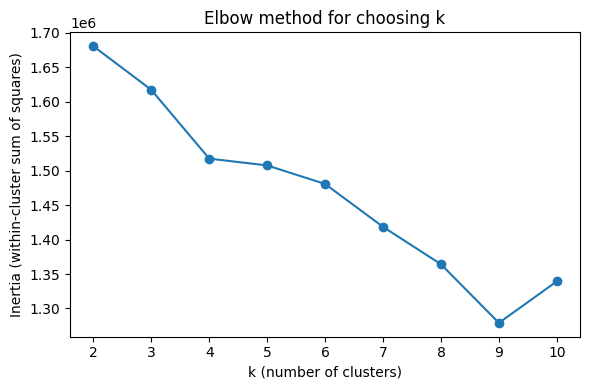

In [39]:
# Elbow method: how does K-Means inertia change as we add more clusters?
# MiniBatchKMeans is used here purely for speed while scanning k.
k_range = range(2, 11)
inertias = []

for k in k_range:
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=1024)
    mbk.fit(user_embeddings)
    inertias.append(mbk.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range), inertias, marker='o')
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow method for choosing k")
plt.tight_layout()
plt.show()


In [40]:
N_CLUSTERS = 5

kmeans_model = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(user_embeddings)


kmeans_silhouette = silhouette_score(user_embeddings, kmeans_labels, sample_size=5000, random_state=42)
kmeans_db = davies_bouldin_score(user_embeddings, kmeans_labels)

print("K-Means cluster sizes:", np.bincount(kmeans_labels))
print(f"Silhouette score:     {kmeans_silhouette:.4f}  (range -1 to 1, higher = better separated)")
print(f"Davies-Bouldin index: {kmeans_db:.4f}  (lower = better separated)")

K-Means cluster sizes: [146197   2431   1685   2759   4102]
Silhouette score:     0.5102  (range -1 to 1, higher = better separated)
Davies-Bouldin index: 1.0376  (lower = better separated)


In [41]:
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

cluster_counts

,count
0,146197
1,2431
2,1685
3,2759
4,4102


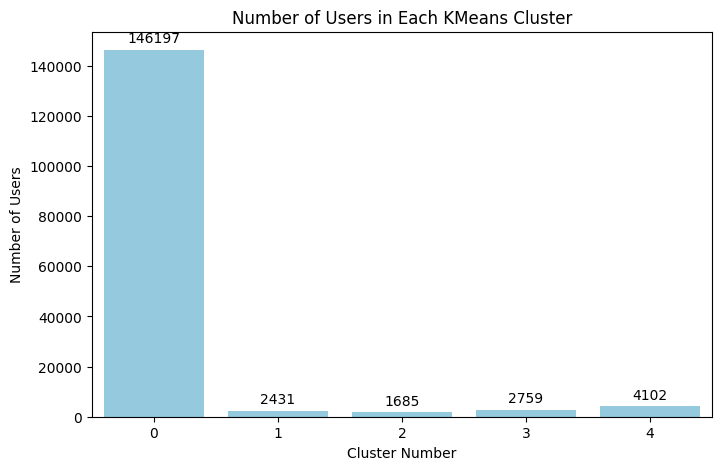

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    color="skyblue"
)

plt.title("Number of Users in Each KMeans Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Users")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

KMeans groups products into clusters based on similar rating behavior. I used 5 clusters here.

In [43]:
import time

t0 = time.time()
kmeans_model_timed = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
_ = kmeans_model_timed.fit_predict(user_embeddings)
kmeans_fit_time = time.time() - t0

t0 = time.time()
mbkmeans_model = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, batch_size=1024)
mbkmeans_labels = mbkmeans_model.fit_predict(user_embeddings)
mbkmeans_fit_time = time.time() - t0

mbkmeans_silhouette = silhouette_score(user_embeddings, mbkmeans_labels, sample_size=5000, random_state=42)
mbkmeans_db = davies_bouldin_score(user_embeddings, mbkmeans_labels)

print("MiniBatchKMeans cluster sizes:", np.bincount(mbkmeans_labels))
print(f"Silhouette score:     {mbkmeans_silhouette:.4f}")
print(f"Davies-Bouldin index: {mbkmeans_db:.4f}")
print(f"\nFit time - full K-Means:      {kmeans_fit_time*1000:.1f} ms")
print(f"Fit time - MiniBatchKMeans:  {mbkmeans_fit_time*1000:.1f} ms")

MiniBatchKMeans cluster sizes: [  2186 146724   2874   3014   2376]
Silhouette score:     0.5066
Davies-Bouldin index: 1.0517

Fit time - full K-Means:      2828.3 ms
Fit time - MiniBatchKMeans:  92.6 ms


In [44]:
mbk_cluster_counts = pd.Series(mbkmeans_labels).value_counts().sort_index()

mbk_cluster_counts

,count
0,2186
1,146724
2,2874
3,3014
4,2376


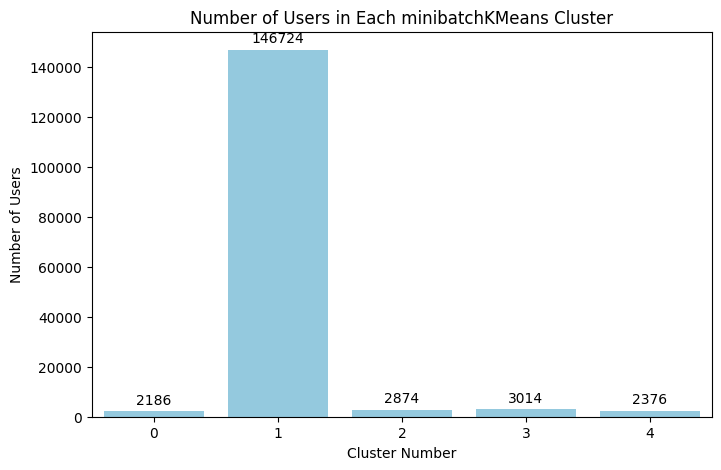

In [45]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=mbk_cluster_counts.index,
    y=mbk_cluster_counts.values,
    color="skyblue"
)

plt.title("Number of Users in Each minibatchKMeans Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Users")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.show()

MiniBatchKMeans is a faster version of KMeans. It is useful for large datasets like this one.

In [46]:
def build_sparse_matrix(data):
    user_ids = data['userid'].unique()
    product_ids = data['productid'].unique()
    user_to_idx = {u: i for i, u in enumerate(user_ids)}
    product_to_idx = {p: i for i, p in enumerate(product_ids)}

    row_idx = data['userid'].map(user_to_idx).values
    col_idx = data['productid'].map(product_to_idx).values
    values = data['ratings'].values

    matrix = csr_matrix((values, (row_idx, col_idx)),
                         shape=(len(user_ids), len(product_ids)))
    return matrix, user_to_idx, product_to_idx, user_ids, product_ids

user_item_matrix, user_to_idx, product_to_idx, user_ids, product_ids = build_sparse_matrix(df_filtered)

density = user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"Matrix shape: {user_item_matrix.shape}  |  non-zero entries: {user_item_matrix.nnz:,}  |  density: {density*100:.3f}%")

Matrix shape: (157174, 32483)  |  non-zero entries: 1,353,204  |  density: 0.027%


In [47]:
def get_svd_embeddings(matrix, n_components=50, random_state=42):
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    embeddings = svd.fit_transform(matrix)
    return svd, embeddings

svd_model, user_embeddings = get_svd_embeddings(user_item_matrix, n_components=50)

print(f"Embeddings shape: {user_embeddings.shape}")
print(f"Variance explained by 50 components: {svd_model.explained_variance_ratio_.sum()*100:.1f}%")

Embeddings shape: (157174, 50)
Variance explained by 50 components: 6.6%


In [48]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import normalize

X = user_embeddings.astype("float32", copy=False)
X = normalize(X)  # good for embeddings

print("Embedding shape:", X.shape)
print("Approx RAM:", X.nbytes / 1e9, "GB")

dbscan_model = DBSCAN(
    eps=0.35,          # start much smaller than 3
    min_samples=10,
    metric="euclidean"
)

dbscan_labels = dbscan_model.fit_predict(X)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
noise_pct = n_noise / len(dbscan_labels) * 100

print(f"DBSCAN found {n_dbscan_clusters} clusters, {n_noise:,} noise points ({noise_pct:.1f}% of users)")

mask = dbscan_labels != -1
clustered_labels = dbscan_labels[mask]

if len(set(clustered_labels)) >= 2:
    rng = np.random.default_rng(42)
    clustered_idx = np.flatnonzero(mask)
    score_idx = rng.choice(clustered_idx, size=min(5000, len(clustered_idx)), replace=False)

    dbscan_silhouette = silhouette_score(X[score_idx], dbscan_labels[score_idx])
    dbscan_db = davies_bouldin_score(X[score_idx], dbscan_labels[score_idx])

    print(f"Silhouette score excluding noise: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin index excluding noise: {dbscan_db:.4f}")
else:
    print("Not enough non-noise clusters to compute silhouette/Davies-Bouldin.")

Embedding shape: (157174, 50)
Approx RAM: 0.0314348 GB
DBSCAN found 499 clusters, 55,625 noise points (35.4% of users)
Silhouette score excluding noise: 0.0482
Davies-Bouldin index excluding noise: 1.1462


In [49]:
dbscan_cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()

dbscan_cluster_counts

,count
-1,55625
0,50085
1,1523
2,273
3,128
...,...
494,6
495,10
496,10
497,10


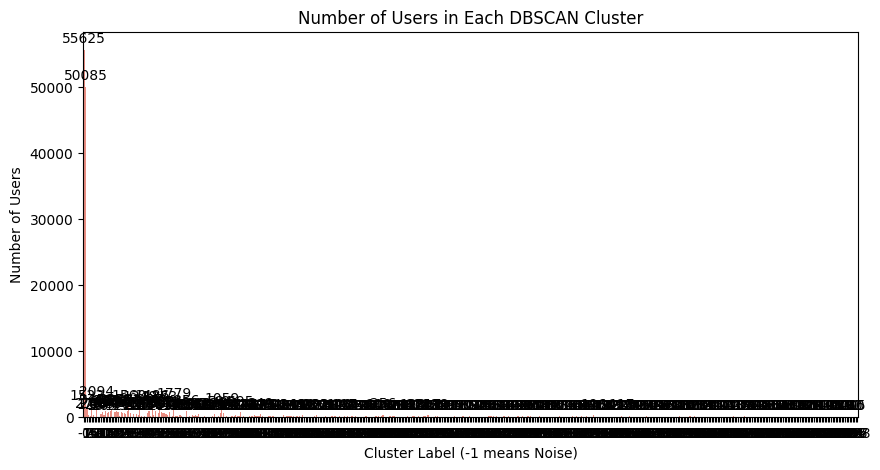

In [50]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=dbscan_cluster_counts.index.astype(str),
    y=dbscan_cluster_counts.values,
    color="salmon"
)

plt.title("Number of Users in Each DBSCAN Cluster")
plt.xlabel("Cluster Label (-1 means Noise)")
plt.ylabel("Number of Users")

for container in ax.containers:
  ax.bar_label(container, fmt="%d", padding=3)

plt.show()

In [54]:
# so we compare it on a representative random subsample. This is a valid comparison
# method (same embedding space, same k, same metrics) but not a substitute for the
# full-data K-Means score above - noted explicitly so it isn't misread as an apples-to-apples number.
rng = np.random.RandomState()
sample_idx = rng.choice(user_embeddings.shape[0], size=3000, replace=False)
embeddings_sample = user_embeddings[sample_idx]

agglo_model = AgglomerativeClustering(n_clusters=N_CLUSTERS)
agglo_labels = agglo_model.fit_predict(embeddings_sample)

agglo_silhouette = silhouette_score(embeddings_sample, agglo_labels)
agglo_db = davies_bouldin_score(embeddings_sample, agglo_labels)

print("Agglomerative cluster sizes (on 3,000-user sample):", np.bincount(agglo_labels))
print(f"Silhouette score:     {agglo_silhouette:.4f}")
print(f"Davies-Bouldin index: {agglo_db:.4f}")

Agglomerative cluster sizes (on 3,000-user sample): [2779   72   55   52   42]
Silhouette score:     0.4824
Davies-Bouldin index: 0.9077


In [55]:
#SAMPLE COMPARISON

sample_size = min(5000, len(product_features))

sample_index = np.random.choice(
    len(product_features),
    size=sample_size,
    replace=False
)

print("KMeans unique clusters:", np.unique(kmeans_labels))
print("MiniBatchKMeans unique clusters:", np.unique(mbkmeans_labels))
print('agglomerative  unique clusters:',np.unique(agglo_labels))
print('db scan unique clusters:',np.unique(dbscan_labels))
comparison = pd.DataFrame({
    "Model": ["K-Means", "MiniBatchKMeans", "DBSCAN",'agglo'],
    "Silhouette (higher=better)": [kmeans_silhouette, mbkmeans_silhouette,dbscan_silhouette,agglo_silhouette],
    "Davies-Bouldin (lower=better)": [kmeans_db, mbkmeans_db, dbscan_db,agglo_db],
    "N clusters": [N_CLUSTERS, N_CLUSTERS, n_dbscan_clusters,N_CLUSTERS],
    "Unassigned users": [0, 0, n_noise,0],
    "Scales to full 20k+ users?": ["Yes", "Yes", "Yes",'Partially'],
})
comparison

KMeans unique clusters: [0 1 2 3 4]
MiniBatchKMeans unique clusters: [0 1 2 3 4]
agglomerative  unique clusters: [0 1 2 3 4]
db scan unique clusters: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 20

,Model,Silhouette (higher=better),Davies-Bouldin (lower=better),N clusters,Unassigned users,Scales to full 20k+ users?
0,K-Means,0.510164,1.037587,5,0,Yes
1,MiniBatchKMeans,0.506582,1.051683,5,0,Yes
2,DBSCAN,0.048220,1.146177,499,55625,Yes
3,agglo,0.482371,0.907708,5,0,Partially


In [56]:
score_df = pd.DataFrame({
    "Model": [
        "KMeans",
        "MiniBatchKMeans",
        "DBSCAN",
        'agglomerative'
    ],
    "Silhouette Score": [
        round(kmeans_silhouette, 4),
        round(mbkmeans_silhouette, 4),
        round(dbscan_silhouette, 4) if "dbscan_silhouette" in globals() else "Not valid",
        round(agglo_silhouette,4)
    ],
    "Davies-Bouldin Score": [
        round(kmeans_db, 4),
        round(mbkmeans_db, 4),
        round(dbscan_db, 4) if "dbscan_db" in globals() else "Not valid",
        round(agglo_db,4)
    ]
})

score_df

,Model,Silhouette Score,Davies-Bouldin Score
0,KMeans,0.5102,1.0376
1,MiniBatchKMeans,0.5066,1.0517
2,DBSCAN,0.0482,1.1462
3,agglomerative,0.4824,0.9077


/tmp/ipykernel_5994/3144427220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


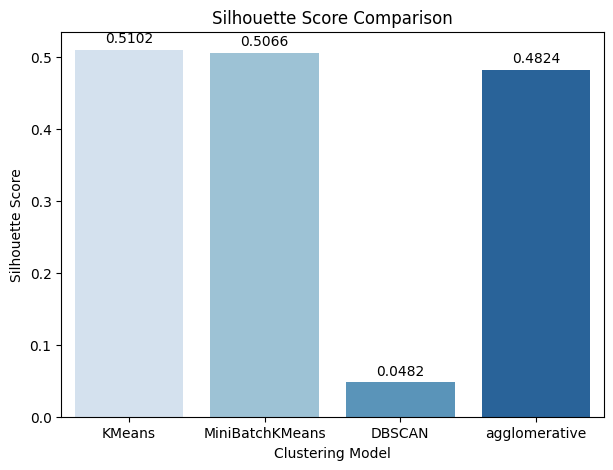

In [57]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=score_df,
    x="Model",
    y="Silhouette Score",
    palette="Blues"
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Clustering Model")
plt.ylabel("Silhouette Score")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.show()

/tmp/ipykernel_5994/3861083224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


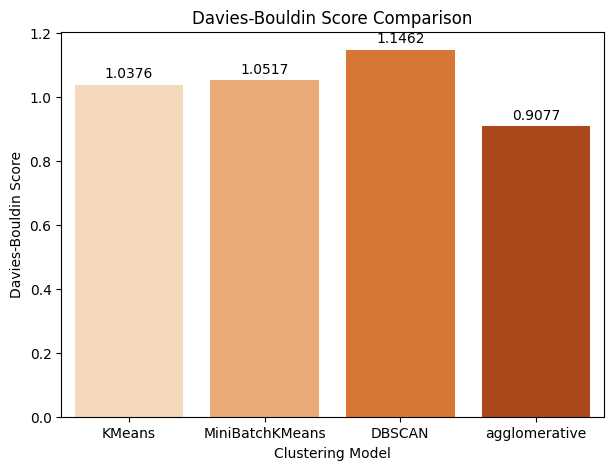

In [58]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=score_df,
    x="Model",
    y="Davies-Bouldin Score",
    palette="Oranges"
)

plt.title("Davies-Bouldin Score Comparison")
plt.xlabel("Clustering Model")
plt.ylabel("Davies-Bouldin Score")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.show()

I evaluated clustering using two metrics. Silhouette Score should be higher. Davies-Bouldin Score should be lower. These metrics help compare which clustering model forms better product groups.

In [59]:
df_filtered = df_filtered.copy()
df_filtered['cluster'] = df_filtered['userid'].map(dict(zip(user_ids, kmeans_labels)))

TOP_N_PER_CLUSTER = 50

def build_popularity_tables(data, cluster_col='cluster'):

    cluster_stats = (data.groupby([cluster_col, 'productid'])['ratings']
                          .agg(['mean', 'count']).reset_index())
    cluster_stats['score'] = cluster_stats['mean'] * np.log1p(cluster_stats['count'])

    cluster_top = {
        c: grp.sort_values('score', ascending=False).head(TOP_N_PER_CLUSTER)['productid'].tolist()
        for c, grp in cluster_stats.groupby(cluster_col)
    }

    global_stats = data.groupby('productid')['ratings'].agg(['mean', 'count']).reset_index()
    global_stats['score'] = global_stats['mean'] * np.log1p(global_stats['count'])
    global_top = global_stats.sort_values('score', ascending=False).head(TOP_N_PER_CLUSTER)['productid'].tolist()

    return cluster_top, global_top

cluster_top_products, global_top_products = build_popularity_tables(df_filtered)
print(f"Built per-cluster popularity lists for {len(cluster_top_products)} clusters")
print(f"Global fallback list: {len(global_top_products)} products")

Built per-cluster popularity lists for 5 clusters
Global fallback list: 50 products


This table shows which cluster each product belongs to. Products in the same cluster have similar rating patterns.

In [60]:
seen_by_user = df_filtered.groupby('userid')['productid'].apply(set).to_dict()
user_cluster_map = dict(zip(user_ids, kmeans_labels))

def recommend(user_id, k=10):
    """Top-k product recommendations for a user, filtering out products they've already rated."""
    already_seen = seen_by_user.get(user_id, set())

    if user_id in user_cluster_map:
        cluster = user_cluster_map[user_id]
        candidates = cluster_top_products.get(cluster, [])
    else:
        candidates = []  # user fell below the min-ratings filter entirely

    recs = [p for p in candidates if p not in already_seen][:k]

    # cold-start / not-enough-candidates fallback: top up with global popularity
    if len(recs) < k:
        backfill = [p for p in global_top_products if p not in recs and p not in already_seen]
        recs += backfill[:k - len(recs)]

    return recs

# Demo on a real user from the filtered dataset
demo_user = user_ids[0]
print(f"User: {demo_user}  |  cluster: {user_cluster_map[demo_user]}")
print(f"Already rated {len(seen_by_user[demo_user])} products")
print(f"Top 10 recommendations: {recommend(demo_user, k=10)}")

User: A20XXTXWF2TCPY  |  cluster: 0
Already rated 5 products
Top 10 recommendations: ['B003ES5ZUU', 'B0019EHU8G', 'B0002L5R78', 'B002V88HFE', 'B000QUUFRW', 'B0052SCU8U', 'B009SYZ8OC', 'B0074BW614', 'B003ELYQGG', 'B00316263Y']


This function recommends products from the same cluster. The idea is that products in the same cluster are similar, so they can be recommended together.

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Popularity-Based Recommendation",
        "Item-Item Collaborative Filtering",
        "KMeans Clustering",
        "MiniBatchKMeans Clustering",
        "Agglomerative Clustering"
    ],

    "Purpose": [
        "Recommend generally popular products",
        "Recommend products similar to a selected product",
        "Group similar products into clusters",
        "Group similar products faster for large data",
        "Group similar users or products step by step by merging the closest items into clusters"
    ],

    "Personalized": [
        "No",
        "Yes",
        "Partially",
        "Partially",
        "Partially"
    ],

    "Evaluation": [
        "Average rating and rating count",
        "Cosine similarity",
        "Silhouette and Davies-Bouldin score",
        "Silhouette and Davies-Bouldin score",
        "Silhouette and Davies-Bouldin score"
    ],

    "Advantage": [
        "Simple and fast",
        "Gives similarity-based recommendations",
        "Easy to understand clusters",
        "Better for large datasets",
        "Shows hierarchical relationship between clusters"
    ],

    "Limitation": [
        "Same recommendations for everyone",
        "Needs enough rating history",
        "Slower on large data",
        "Approximate clustering",
        "Very slow and memory-heavy for large datasets"
    ]
})

comparison

comparison

,Model,Purpose,Personalized,Evaluation,Advantage,Limitation
0,Popularity-Based Recommendation,Recommend generally popular products,No,Average rating and rating count,Simple and fast,Same recommendations for everyone
1,Item-Item Collaborative Filtering,Recommend products similar to a selected product,Yes,Cosine similarity,Gives similarity-based recommendations,Needs enough rating history
2,KMeans Clustering,Group similar products into clusters,Partially,Silhouette and Davies-Bouldin score,Easy to understand clusters,Slower on large data
3,MiniBatchKMeans Clustering,Group similar products faster for large data,Partially,Silhouette and Davies-Bouldin score,Better for large datasets,Approximate clustering
4,Agglomerative Clustering,Group similar users or products step by step b...,Partially,Silhouette and Davies-Bouldin score,Shows hierarchical relationship between clusters,Very slow and memory-heavy for large datasets


In [62]:
evaluation_df = pd.DataFrame({
    "Model": ["KMeans", "MiniBatchKMeans",'dbscan','agglomerative'],
    "Silhouette Score": [kmeans_silhouette, mbkmeans_silhouette,dbscan_silhouette,agglo_silhouette],
    "Davies-Bouldin Score": [kmeans_db, mbkmeans_db,dbscan_db,agglo_db],
})

evaluation_df

,Model,Silhouette Score,Davies-Bouldin Score
0,KMeans,0.510164,1.037587
1,MiniBatchKMeans,0.506582,1.051683
2,dbscan,0.048220,1.146177
3,agglomerative,0.482371,0.907708


In [63]:
popularity_eval = {
    "Model": "Popularity-Based Recommendation",
    "Evaluation Metric": "Average rating and rating count",
    "Average Rating of Top Products": round(popular_products["average_rating"].head(10).mean(), 4),
    "Average Rating Count of Top Products": round(popular_products["rating_count"].head(10).mean(), 2)
}

popularity_eval

{'Model': 'Popularity-Based Recommendation',
 'Evaluation Metric': 'Average rating and rating count',
 'Average Rating of Top Products': np.float64(4.9305),
 'Average Rating Count of Top Products': np.float64(80.8)}

In [64]:
item_based_eval = {
    "Model": "Item-Item Collaborative Filtering",
    "Evaluation Metric": "Cosine similarity",
    "Average Similarity Score": round(similar_products["similarity_score"].mean(), 4),
    "Highest Similarity Score": round(similar_products["similarity_score"].max(), 4)
}

item_based_eval

{'Model': 'Item-Item Collaborative Filtering',
 'Evaluation Metric': 'Cosine similarity',
 'Average Similarity Score': np.float64(0.3918),
 'Highest Similarity Score': 0.8321}

In [65]:
recommendation_eval_df = pd.DataFrame([
    popularity_eval,
    item_based_eval
])

recommendation_eval_df

,Model,Evaluation Metric,Average Rating of Top Products,Average Rating Count of Top Products,Average Similarity Score,Highest Similarity Score
0,Popularity-Based Recommendation,Average rating and rating count,4.9305,80.8,NaN,NaN
1,Item-Item Collaborative Filtering,Cosine similarity,NaN,NaN,0.3918,0.8321


In [66]:
import os
import pickle
import numpy as np

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [67]:
mbkmeans_user_cluster_map = dict(zip(user_ids, mbkmeans_labels))

df_model_save = df_filtered.copy()
df_model_save["mbkmeans_cluster"] = df_model_save["userid"].map(mbkmeans_user_cluster_map)


def build_cluster_top_products(data, cluster_col, top_n=50):
    cluster_stats = (
        data.groupby([cluster_col, "productid"])["ratings"]
        .agg(["mean", "count"])
        .reset_index()
    )

    cluster_stats["score"] = cluster_stats["mean"] * np.log1p(cluster_stats["count"])

    cluster_top_products = {
        cluster: group.sort_values("score", ascending=False)
        .head(top_n)["productid"]
        .tolist()
        for cluster, group in cluster_stats.groupby(cluster_col)
    }

    return cluster_top_products


mbkmeans_cluster_top_products = build_cluster_top_products(
    df_model_save,
    "mbkmeans_cluster"
)


In [68]:
model_bundle = {
    "kmeans_model": kmeans_model,
    "minibatch_kmeans_model": mbkmeans_model,
    "svd_model": svd_model,
    "cosine_model": item_model,

    "user_item_matrix": user_item_matrix,

    "user_ids": user_ids,
    "product_ids": product_ids,
    "user_to_idx": user_to_idx,
    "product_to_idx": product_to_idx,

    "kmeans_labels": kmeans_labels,
    "minibatch_labels": mbkmeans_labels,

    "kmeans_user_cluster_map": user_cluster_map,
    "minibatch_user_cluster_map": mbkmeans_user_cluster_map,

    "kmeans_cluster_top_products": cluster_top_products,
    "minibatch_cluster_top_products": mbkmeans_cluster_top_products,

    "global_top_products": global_top_products,
    "seen_by_user": seen_by_user,
    "popular_products": popular_products
}

pickle_path = os.path.join(MODEL_DIR, "product_recommendation_models.pkl")

with open(pickle_path, "wb") as file:
    pickle.dump(model_bundle, file)

print("Model pickle file saved successfully:")
print(pickle_path)

Model pickle file saved successfully:
models/product_recommendation_models.pkl


In [69]:
with open("models/product_recommendation_models.pkl", "rb") as file:
    loaded_model_bundle = pickle.load(file)

print("Pickle loaded successfully")
print("Available objects:")
print(loaded_model_bundle.keys())

Pickle loaded successfully
Available objects:
dict_keys(['kmeans_model', 'minibatch_kmeans_model', 'svd_model', 'cosine_model', 'user_item_matrix', 'user_ids', 'product_ids', 'user_to_idx', 'product_to_idx', 'kmeans_labels', 'minibatch_labels', 'kmeans_user_cluster_map', 'minibatch_user_cluster_map', 'kmeans_cluster_top_products', 'minibatch_cluster_top_products', 'global_top_products', 'seen_by_user', 'popular_products'])


In [76]:
import shutil
import joblib
from google.colab import files

shutil.make_archive("models", "zip", "models")
joblib.dump(model_bundle,'models/product_recommendation_models.joblib')
files.download('models/product_recommendation_models.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## model deployment